In [93]:
import pandas as pd
import requests
import time
import json
import matplotlib.pyplot as plt
import numpy as np

from collections import Counter
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV



In [4]:
def get_owners(appid):
    '''fetch owner data of specific appid from SteamSpy'''

    url = f"https://steamspy.com/api.php?request=appdetails&appid={appid}"
    
    try:
        response = requests.get(url, timeout=10)
        data = response.json()

        # if there is no result, return "0 .. 0"
        return data.get("owners", "0 .. 0")
    except Exception:
        return None

# file paths
input_file = "../steam_1000.jsonl"
output_file = "steam_with_owners.jsonl"

#iter over input file, fetch owners data, and write to output file
with open(input_file, "r", encoding="utf-8") as f_in, \
     open(output_file, "w", encoding="utf-8") as f_out:
    
    for i, line in enumerate(f_in, start=1):
        game = json.loads(line)

        # only fetch if "owners_range" is missing or "0 .. 0"
        if "owners_range" not in game or game["owners_range"] == "0 .. 0":

            # get appid and fetch owners data
            appid = game.get("steam_appid")
            owners = get_owners(appid)

            if owners:
                game["owners_range"] = owners
                time.sleep(1.0) 
        
        # write game data to output file
        f_out.write(json.dumps(game, ensure_ascii=False) + "\n")

        if i % 50 == 0:
            print(i, "line processed")
        
        time.sleep(1.0)

50 line processed
100 line processed
150 line processed
200 line processed
250 line processed
300 line processed
350 line processed
400 line processed
450 line processed
500 line processed
550 line processed
600 line processed
650 line processed
700 line processed
750 line processed
800 line processed
850 line processed
900 line processed
950 line processed
1000 line processed


In [27]:
# analyze the distribution of owner ranges

range_counter = Counter()

with open(output_file, 'r', encoding='utf-8') as f:
    for line in f:
        if line.strip():
            data = json.loads(line)

            # if "owners_range" is missing, count it as "Unknown"
            owner_range = data.get("owners_range", "Unknown")
            range_counter[owner_range] += 1
            
def get_lower_bound(range_str):
    '''extract the lower bound of the owner range for sorting'''
    if range_str == "Unknown":
        return -1 
    return int(range_str.split(' .. ')[0].replace(',', ''))

# sort the owner ranges by their lower bound
sorted_items = sorted(range_counter.items(), key=lambda item: get_lower_bound(item[0]))

# print the sorted distribution
sorted_keys = [item[0] for item in sorted_items]
sorted_values = [item[1] for item in sorted_items]

print("Owner Range Distribution (Sorted by Size):")
for k, v in sorted_items:
    print(f"{k}: {v} games")

print(f"Total games: {sum(sorted_values)}")


Owner Range Distribution (Sorted by Size):
0 .. 20,000: 262 games
20,000 .. 50,000: 24 games
50,000 .. 100,000: 39 games
100,000 .. 200,000: 73 games
200,000 .. 500,000: 111 games
500,000 .. 1,000,000: 110 games
1,000,000 .. 2,000,000: 154 games
2,000,000 .. 5,000,000: 126 games
5,000,000 .. 10,000,000: 48 games
10,000,000 .. 20,000,000: 26 games
20,000,000 .. 50,000,000: 21 games
50,000,000 .. 100,000,000: 4 games
100,000,000 .. 200,000,000: 2 games
Total games: 1000


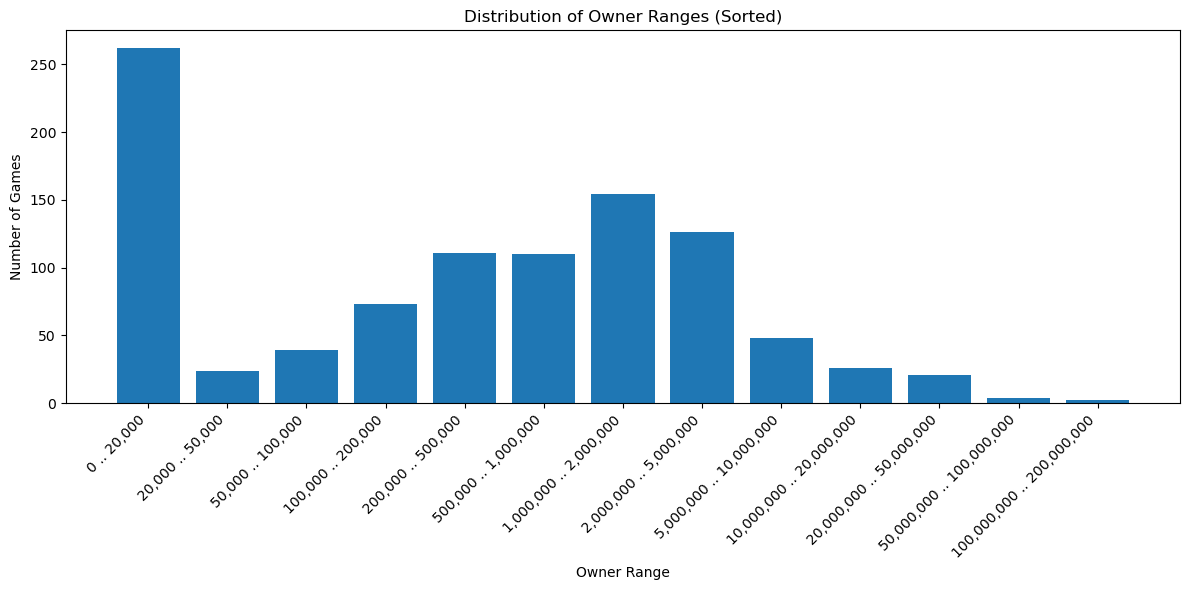

In [30]:
# visualize the distribution with a bar chart
plt.figure(figsize=(12, 6))
plt.bar(sorted_keys, sorted_values)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Owner Range')
plt.ylabel('Number of Games')
plt.title('Distribution of Owner Ranges (Sorted)')
plt.tight_layout()
plt.show()

In [ ]:
FILE_PATH = "steam_with_owners.jsonl"
data_list = []

with open(FILE_PATH, "r", encoding="utf-8") as f:
    for line in f:
        if not line.strip():
            continue
            
        game = json.loads(line)
        
        # Safely extract nested structures
        languages = game.get("supported_languages", "")
        price = game.get("price_overview", {})
        platforms = game.get("platforms", {})
        achievements = game.get("achievements", {})
        genres_data = game.get("genres", [])
        
        # Parse language count safely handling empty strings
        lang_list = [lang for lang in languages.split(",") if lang]
        
        row = {
            "appid": game.get("steam_appid"),
            "owners_range": game.get("owners_range", "0 .. 0"),
            
            # Continuous / Integer features
            "lang_count": len(lang_list),
            "cat_count": len(game.get("categories", [])),
            "genre_count": len(genres_data),
            "initial_price": price.get("initial", 0),
            "dlc_count": len(game.get("dlc", [])),
            "achievement_count": achievements.get("total", 0),
            
            # Binary features (0 or 1)
            "has_chinese": 1 if "Simplified Chinese" in languages else 0,
            "has_mac": 1 if platforms.get("mac") else 0,
            "has_controller": 1 if game.get("controller_support") else 0,
            
            # Raw categorical feature
            "genres": [g.get("description") for g in genres_data]
        }
        data_list.append(row)

df = pd.DataFrame(data_list)

# Verify the DataFrame structure
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   appid              1000 non-null   int64 
 1   owners_range       1000 non-null   object
 2   lang_count         1000 non-null   int64 
 3   cat_count          1000 non-null   int64 
 4   genre_count        1000 non-null   int64 
 5   initial_price      1000 non-null   int64 
 6   dlc_count          1000 non-null   int64 
 7   achievement_count  1000 non-null   int64 
 8   has_chinese        1000 non-null   int64 
 9   has_mac            1000 non-null   int64 
 10  has_controller     1000 non-null   int64 
 11  genres             1000 non-null   object
dtypes: int64(10), object(2)
memory usage: 93.9+ KB
None


In [34]:
df.head()

,appid,owners_range,lang_count,cat_count,genre_count,initial_price,dlc_count,achievement_count,has_chinese,has_mac,has_controller,genres
0,206420,"5,000,000 .. 10,000,000",8,12,2,1999,0,73,0,0,1,"[Action, Adventure]"
1,1888160,"2,000,000 .. 5,000,000",13,14,1,5999,0,30,1,0,0,[Action]
2,2076140,"20,000 .. 50,000",5,11,4,1799,8,49,1,1,1,"[Adventure, Casual, Indie, Simulation]"
3,312980,"50,000 .. 100,000",2,5,2,3499,30,39,0,0,0,"[Simulation, Strategy]"
4,2022670,"200,000 .. 500,000",13,15,1,5999,8,38,1,0,1,[Action]


In [ ]:
# Unnest the lists in the 'genres' column to individual rows, then compute frequencies
genre_counts = df['genres'].explode().value_counts()

print("genre count：")
print(genre_counts)

# check the total number of unique genres
unique_genre_count = genre_counts.shape[0]
print(f"\ntotal unique genres: {unique_genre_count}")

genre count：
genres
Action                   544
Adventure                418
Indie                    408
Simulation               312
RPG                      296
Strategy                 225
Casual                   193
Early Access             127
Free To Play             106
Massively Multiplayer     73
Sports                    56
Racing                    48
Utilities                  5
Animation & Modeling       4
Design & Illustration      3
Game Development           3
Video Production           3
Audio Production           2
Photo Editing              2
Education                  1
Web Publishing             1
Name: count, dtype: int64

total unique genres: 21


In [36]:
# one-hot encode the 'genres' column
mlb = MultiLabelBinarizer()

genres_encoded = pd.DataFrame(
    mlb.fit_transform(df['genres']),
    columns=mlb.classes_,
    index=df.index
)

# filter out genres that appear in less than 48 games
genre_counts = genres_encoded.sum()
top_genres = genre_counts[genre_counts >= 48].index.tolist()

# make final genre features with prefix, and merge back to original DataFrame
genres_final = genres_encoded[top_genres].add_prefix('is_')
df = pd.concat([df.drop(columns=['genres']), genres_final], axis=1)

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   appid                     1000 non-null   int64 
 1   owners_range              1000 non-null   object
 2   lang_count                1000 non-null   int64 
 3   cat_count                 1000 non-null   int64 
 4   genre_count               1000 non-null   int64 
 5   initial_price             1000 non-null   int64 
 6   dlc_count                 1000 non-null   int64 
 7   achievement_count         1000 non-null   int64 
 8   has_chinese               1000 non-null   int64 
 9   has_mac                   1000 non-null   int64 
 10  has_controller            1000 non-null   int64 
 11  is_Action                 1000 non-null   int32 
 12  is_Adventure              1000 non-null   int32 
 13  is_Casual                 1000 non-null   int32 
 14  is_Early Access          

In [ ]:
# get the lower bound of owner range for each row
df['lower_bound'] = df['owners_range'].apply(get_lower_bound)

# rank the lower bounds to create a new integer target variable (owners_level)
df['owners_level'] = df['lower_bound'].rank(method='dense').astype(int)

df = df.drop(columns=['owners_range', 'lower_bound'])


In [40]:
print(df['owners_level'].value_counts().sort_index())

owners_level
1     262
2      24
3      39
4      73
5     111
6     110
7     154
8     126
9      48
10     26
11     21
12      4
13      2
Name: count, dtype: int64


In [ ]:
# combine owner levels into 4 classes based on the defined bins, avoid levels with very few samples
bins = [0, 1, 5, 8, float('inf')]
labels = [1, 2, 3, 4]

df['owners_class'] = pd.cut(df['owners_level'], bins=bins, labels=labels).astype(int)
df = df.drop(columns=['owners_level'])



KeyError: 'owners_level'

In [48]:
print(df['owners_class'].value_counts().sort_index())

owners_class
1    262
2    247
3    390
4    101
Name: count, dtype: int64


In [ ]:
dates = []

# 1. Extract raw date strings maintaining strict row order
with open(FILE_PATH, "r", encoding="utf-8") as f:
    for line in f:
        if not line.strip():
            continue
        game = json.loads(line)
        # Safely extract the date string; fallback to empty string
        date_str = game.get("release_date", {}).get("date", "")
        dates.append(date_str)

# Parse strings to datetime objects
# errors='coerce' forces unparseable strings (e.g., "Q3 2021") to NaT (Not a Time)
parsed_dates = pd.to_datetime(pd.Series(dates), format='mixed', errors='coerce')

current_time = pd.Timestamp.now()
days_since_release = (current_time - parsed_dates).dt.days

# Impute missing values (NaT -> NaN) using the median to preserve distribution
days_since_release = days_since_release.fillna(days_since_release.median())

# Append the new feature to the existing DataFrame
df['days_since_release'] = days_since_release.astype(int)

In [80]:
# check the new feature
print(df['days_since_release'].describe())

count    1000.000000
mean     1490.342000
std      1514.471866
min      -151.000000
25%       291.000000
50%       941.000000
75%      2189.500000
max      9971.000000
Name: days_since_release, dtype: float64


In [ ]:
# check future releases
future_releases = df[df['days_since_release'] < 0]
print(f"future releases: {len(future_releases)}")

if len(future_releases) > 0:
    print(future_releases[['appid', 'days_since_release']].head())

df = df[df['days_since_release'] >= 0].copy()

df = df.reset_index(drop=True)

print(f"\ntotal number of valid samples: {len(df)}")

future releases: 8
       appid  days_since_release
15   3768760                 -80
95   3787240                -151
484  2157830                  -4
500  2814990                 -18
545  2852190                  -4

total number of valid samples: 992


In [83]:
future_releases = df[df['days_since_release'] < 0]
print(f"future releases: {len(future_releases)}")

future releases: 0


In [87]:
# log transform 'days_since_release'
df['log_days_since_release'] = np.log1p(df['days_since_release'])
df = df.drop(columns=['days_since_release'])

In [99]:
X = df.drop(columns=['appid', 'owners_class'])
y = df['owners_class']

# split dataset to 80% training and 20% testing
# stratefy = y: ensure the proportion of each owners_class is maintained in both training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) 


# train a random forest classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# model evaluation
y_pred = rf_model.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           1       0.86      0.94      0.90        51
           2       0.68      0.54      0.60        50
           3       0.65      0.81      0.72        78
           4       0.33      0.10      0.15        20

    accuracy                           0.70       199
   macro avg       0.63      0.60      0.59       199
weighted avg       0.68      0.70      0.68       199



In [ ]:
# grid search for hyperparameter tuning of Random Forest
# Define the parameter grid
# Focused on controlling overfitting and handling class imbalance
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 12, 15, 17, 20],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': ['balanced', 'balanced_subsample']
}
# n_estimators: number of trees in the forest
# max_depth: maximum depth of each tree (None means no limit)
# min_samples_leaf: minimum number of samples required to be at a leaf node
# class_weight: 'balanced' uses the values of y to automatically adjust weights inversely proportional to class frequencies, 
# while 'balanced_subsample' help with imbalanced datasets.

# Instantiate GridSearchCV
# scoring='f1_macro' forces the search to prioritize performance across all classes equally
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=param_grid,
    cv=5, # 5-fold cross-validation
    scoring='f1_macro',
    n_jobs=-1
)

# Execute grid search on training data
grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

# Evaluate the best model found by grid search
best_rf_model = grid_search.best_estimator_
y_pred_optimized = best_rf_model.predict(X_test)
print(classification_report(y_test, y_pred_optimized))

Best Parameters:
{'class_weight': 'balanced_subsample', 'max_depth': 10, 'min_samples_leaf': 4, 'n_estimators': 100}
              precision    recall  f1-score   support

           1       0.83      0.94      0.88        51
           2       0.63      0.68      0.65        50
           3       0.70      0.62      0.65        78
           4       0.28      0.25      0.26        20

    accuracy                           0.68       199
   macro avg       0.61      0.62      0.61       199
weighted avg       0.67      0.68      0.67       199



In [100]:
feature_importances = pd.Series(best_rf_model.feature_importances_, index=X.columns)
print("\nTop 10 important features:")
print(feature_importances.sort_values(ascending=False).head(20))


Top 10 important features:
log_days_since_release      0.386764
achievement_count           0.094422
cat_count                   0.094088
initial_price               0.078725
lang_count                  0.070951
dlc_count                   0.063842
genre_count                 0.035000
is_Action                   0.031977
is_Free To Play             0.015991
is_Indie                    0.014939
is_Simulation               0.014435
is_RPG                      0.014029
has_chinese                 0.013104
is_Adventure                0.012070
has_controller              0.011468
has_mac                     0.011447
is_Casual                   0.010385
is_Strategy                 0.010369
is_Early Access             0.007201
is_Massively Multiplayer    0.004918
dtype: float64


In [102]:
train_accuracy = best_rf_model.score(X_train, y_train)
test_accuracy = best_rf_model.score(X_test, y_test)

print(f"Training Accuracy: {train_accuracy:.2f}")
print(f"Testing Accuracy: {test_accuracy:.2f}")

Training Accuracy: 0.85
Testing Accuracy: 0.68
